In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import math

In [15]:
df = pd.read_csv("F:/MyProjects/MarketMind-AI/data/raw/transactions.csv")
df.head()

,transaction_id,customer_id,order_date,payment_method,order_status,subtotal,discount,tax,shipping_charge,final_amount,coupon_code,delivery_days,returned,delivery_city,delivery_state
0,1,30291,2024-04-01 00:00:00,Net Banking,Delivered,14367.86,2058.53,2215.68,0.0,14525.01,SAVE10,7.0,False,Vadodara,Gujarat
1,2,23635,2024-01-23 00:00:00,Credit Card,Processing,24091.93,1702.95,4030.02,0.0,26419.00,BF30,5.0,False,Faridabad,Haryana
2,3,1731,2021-07-22 00:00:00,Wallet,Cancelled,44497.97,2534.32,7553.46,0.0,49517.11,NaN,NaN,False,Bhopal,Madhya Pradesh
3,4,10280,2022-07-27 00:00:00,BNPL,Cancelled,17668.40,255.61,3134.30,0.0,20547.09,FESTIVE15,NaN,False,Vadodara,Gujarat
4,5,219,2023-11-05 00:00:00,Debit Card,Returned,17699.91,332.66,3126.11,0.0,20493.36,FESTIVE15,NaN,True,Lucknow,Uttar Pradesh


In [16]:
display(df.shape)
display(df.columns)

(500000, 15)

Index(['transaction_id', 'customer_id', 'order_date', 'payment_method',
       'order_status', 'subtotal', 'discount', 'tax', 'shipping_charge',
       'final_amount', 'coupon_code', 'delivery_days', 'returned',
       'delivery_city', 'delivery_state'],
      dtype='object')

In [17]:
df.isnull().sum().sum()

np.int64(291220)

<Axes: >

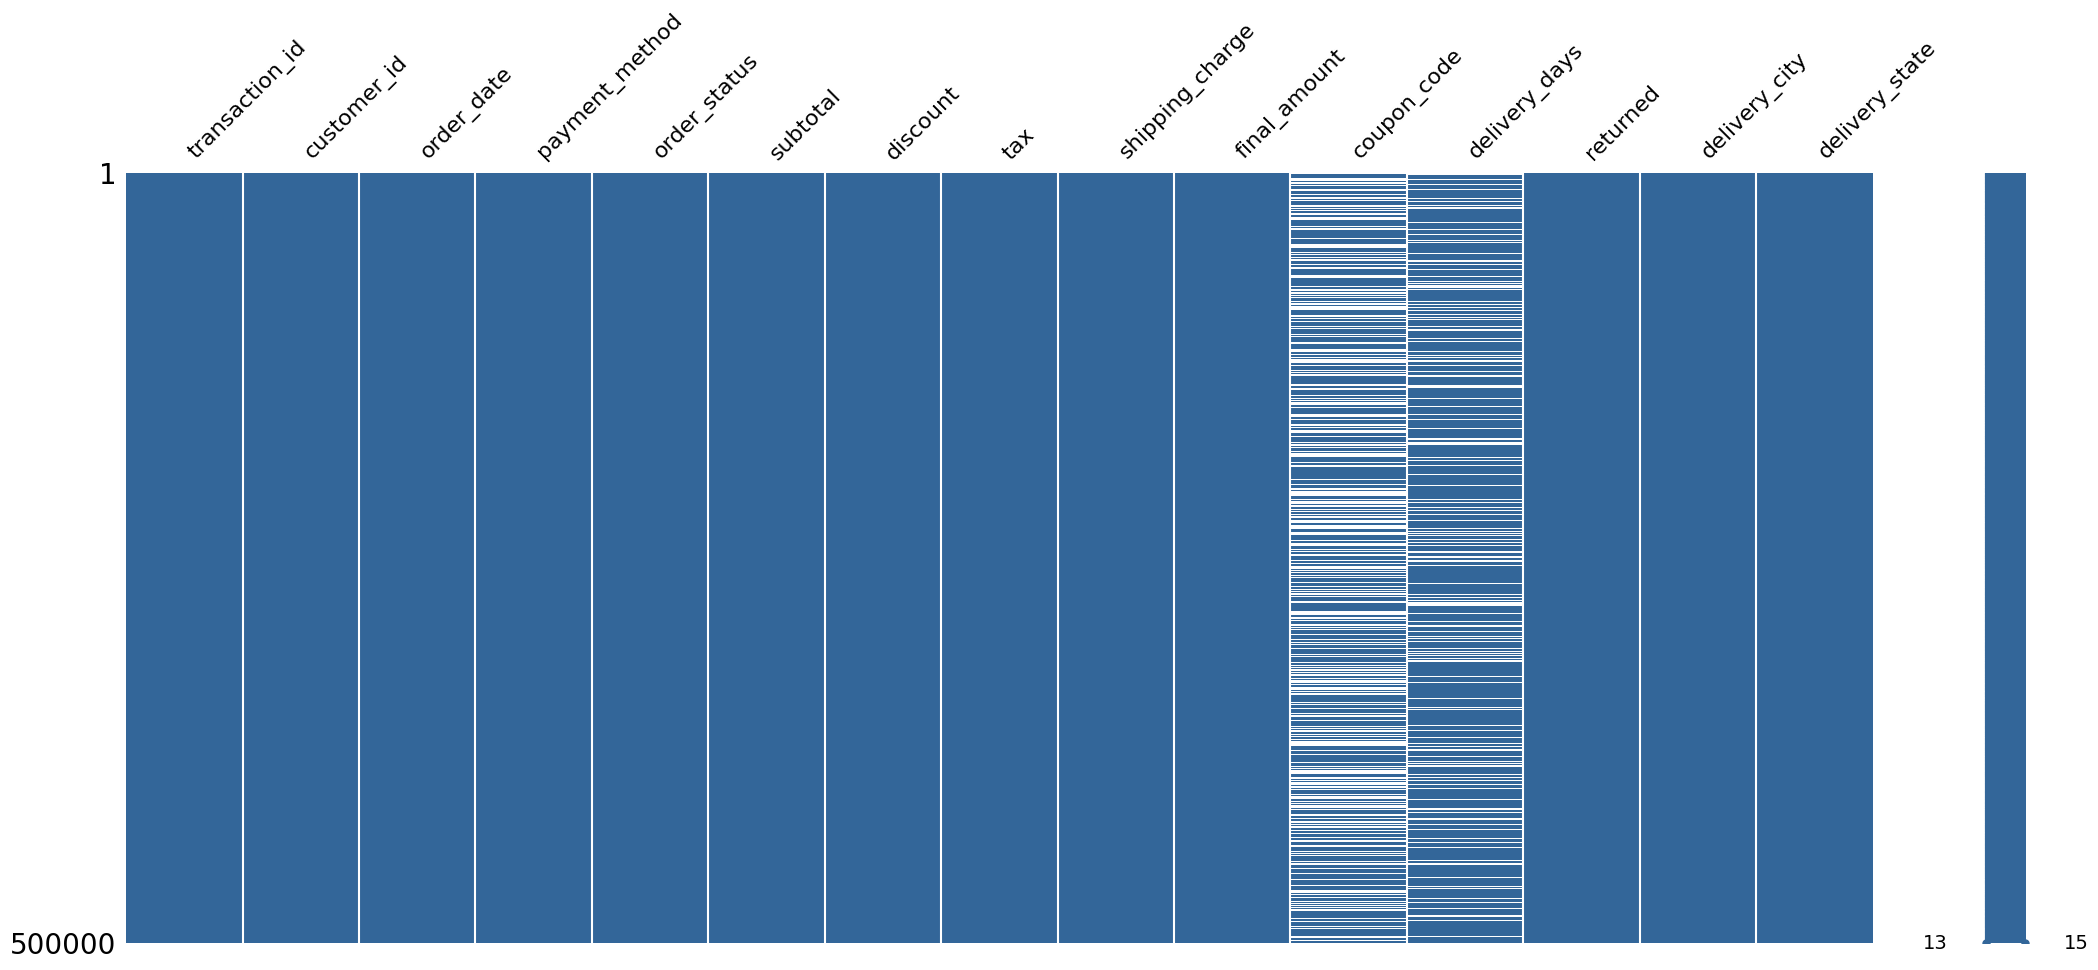

In [18]:
msno.matrix(df, color=(0.2, 0.4, 0.6))

In [19]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)

transaction_id      0.0000
customer_id         0.0000
order_date          0.0000
payment_method      0.0000
order_status        0.0000
subtotal            0.0000
discount            0.0000
tax                 0.0000
shipping_charge     0.0000
final_amount        0.0000
coupon_code        40.0908
delivery_days      18.1532
returned            0.0000
delivery_city       0.0000
delivery_state      0.0000
dtype: float64


In [20]:
df['delivery_days'] = df['delivery_days'].fillna(df['delivery_days'].median())

In [21]:
df = df.drop(columns='coupon_code')

np.int64(0)

<Axes: >

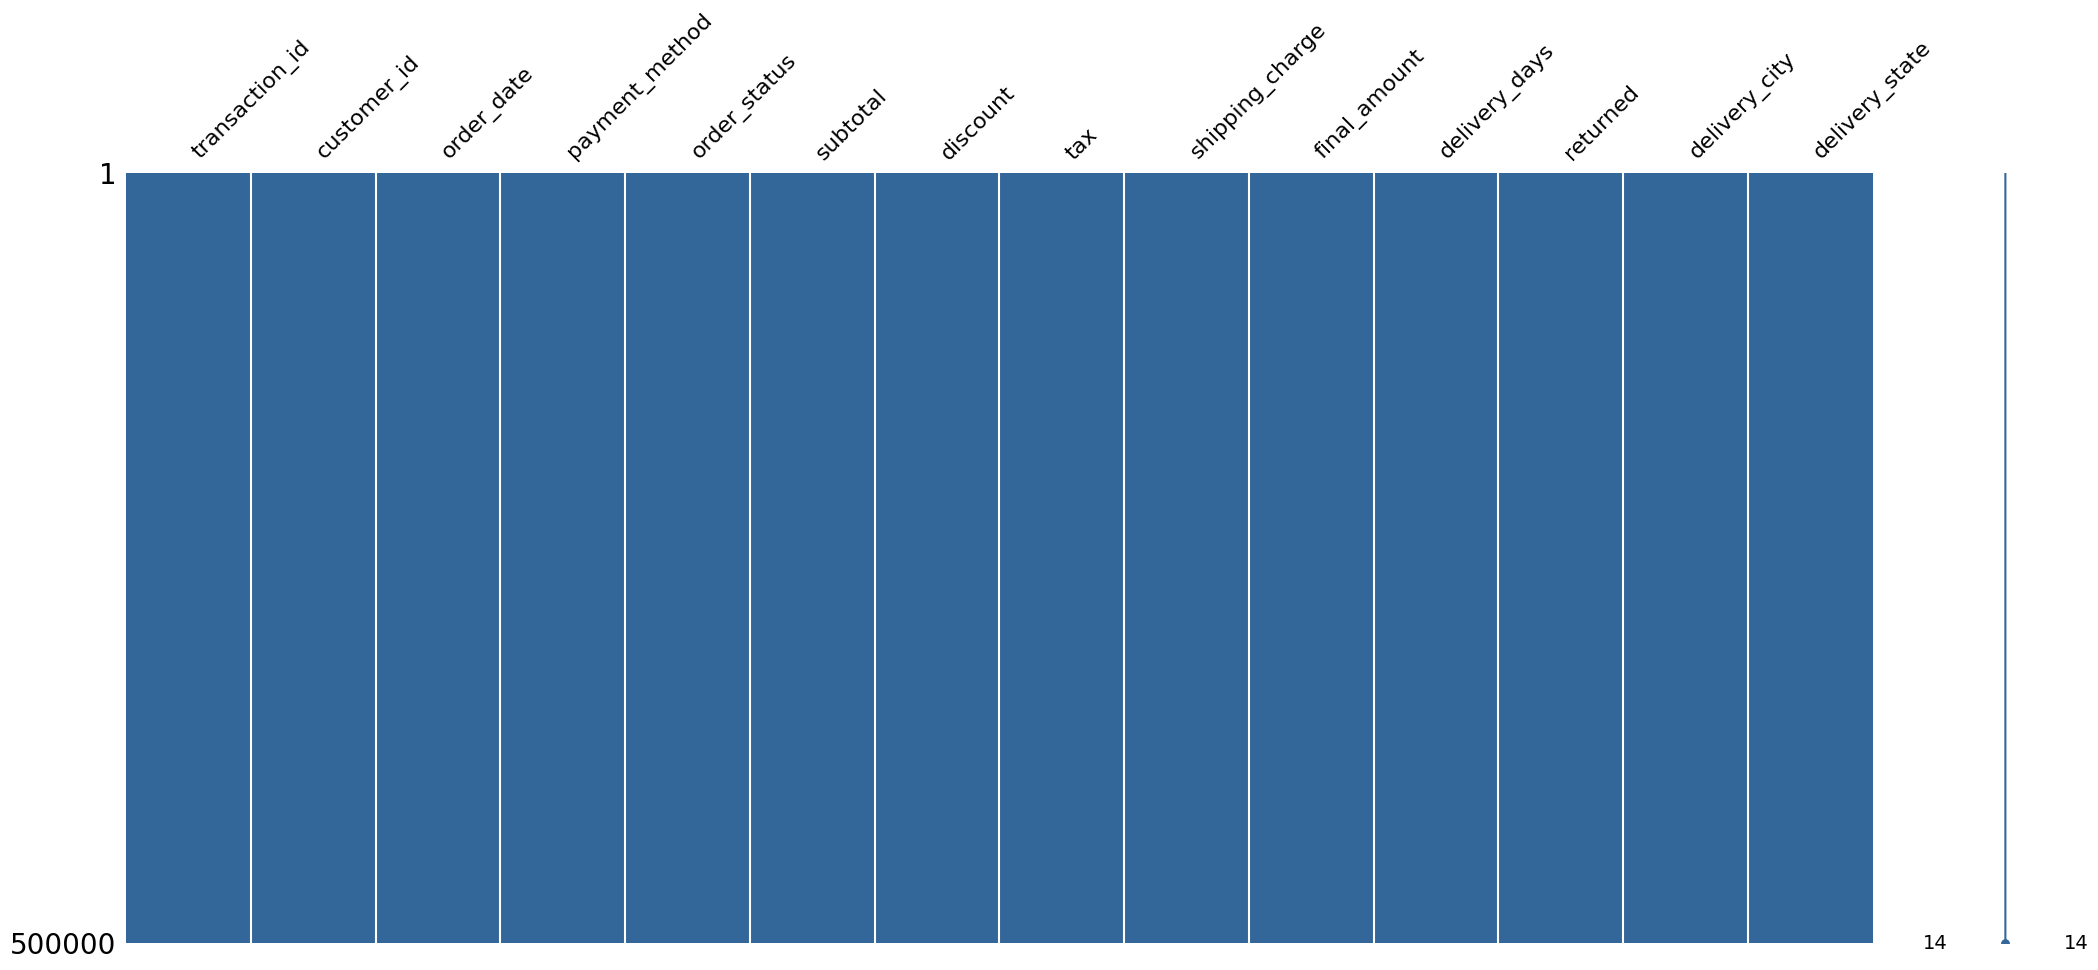

In [22]:
display(df.isnull().sum().sum())
msno.matrix(df, color=(0.2, 0.4, 0.6))

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   transaction_id   500000 non-null  int64  
 1   customer_id      500000 non-null  int64  
 2   order_date       500000 non-null  object 
 3   payment_method   500000 non-null  object 
 4   order_status     500000 non-null  object 
 5   subtotal         500000 non-null  float64
 6   discount         500000 non-null  float64
 7   tax              500000 non-null  float64
 8   shipping_charge  500000 non-null  float64
 9   final_amount     500000 non-null  float64
 10  delivery_days    500000 non-null  float64
 11  returned         500000 non-null  bool   
 12  delivery_city    500000 non-null  object 
 13  delivery_state   500000 non-null  object 
dtypes: bool(1), float64(6), int64(2), object(5)
memory usage: 50.1+ MB


In [25]:
df = df.sort_values(by=[ "order_date"])

In [26]:
df.head()

,transaction_id,customer_id,order_date,payment_method,order_status,subtotal,discount,tax,shipping_charge,final_amount,delivery_days,returned,delivery_city,delivery_state
353368,353369,2386,2021-01-01 00:00:00,UPI,Delivered,12991.73,424.01,2262.19,0.0,14829.91,10.0,False,Nashik,Maharashtra
170591,170592,15471,2021-01-01 00:00:00,UPI,Delivered,85817.06,2455.30,15005.12,0.0,98366.88,10.0,False,Chennai,Tamil Nadu
432704,432705,9358,2021-01-01 00:00:00,COD,Delivered,6659.58,45.18,1190.59,0.0,7804.99,3.0,False,Patna,Bihar
92393,92394,28762,2021-01-01 00:00:00,Debit Card,Shipped,9873.83,664.84,1657.62,0.0,10866.61,8.0,False,Lucknow,Uttar Pradesh
375201,375202,4128,2021-01-01 00:00:00,Credit Card,Delivered,16889.15,808.18,2894.57,0.0,18975.54,6.0,False,Visakhapatnam,Andhra Pradesh


In [27]:
df.tail()

,transaction_id,customer_id,order_date,payment_method,order_status,subtotal,discount,tax,shipping_charge,final_amount,delivery_days,returned,delivery_city,delivery_state
255034,255035,39732,2024-12-28 00:00:00,Credit Card,Shipped,22199.34,481.63,3909.19,0.0,25626.90,10.0,False,Kochi,Kerala
232624,232625,34136,2024-12-28 00:00:00,Net Banking,Delivered,26321.33,1037.98,4551.00,0.0,29834.35,10.0,False,Nashik,Maharashtra
62799,62800,2685,2024-12-28 00:00:00,Debit Card,Delivered,4657.74,169.21,807.94,0.0,5296.47,9.0,False,Indore,Madhya Pradesh
497891,497892,42605,2024-12-28 00:00:00,Wallet,Delivered,5969.10,50.30,1065.38,0.0,6984.18,5.0,False,Coimbatore,Tamil Nadu
104622,104623,16439,2024-12-28 00:00:00,UPI,Cancelled,4026.49,184.19,691.61,0.0,4533.91,5.0,False,Kolkata,West Bengal


In [ ]:
# df.to_csv("F:/MyProjects/MarketMind-AI/notebooks/ordered_trans.csv", index=False)

In [30]:
num_cols = df.select_dtypes(include = ['float','int64']).columns.tolist()
display(len(num_cols))
display(num_cols)

8

['transaction_id',
 'customer_id',
 'subtotal',
 'discount',
 'tax',
 'shipping_charge',
 'final_amount',
 'delivery_days']

In [31]:
cat_cols = df.select_dtypes(include = ['object']).columns.tolist()
display(len(cat_cols))
display(cat_cols)

5

['order_date',
 'payment_method',
 'order_status',
 'delivery_city',
 'delivery_state']

In [32]:
display(df[num_cols].shape)
display(df[num_cols].columns)
df[num_cols].head()

(500000, 8)

Index(['transaction_id', 'customer_id', 'subtotal', 'discount', 'tax',
       'shipping_charge', 'final_amount', 'delivery_days'],
      dtype='object')

,transaction_id,customer_id,subtotal,discount,tax,shipping_charge,final_amount,delivery_days
353368,353369,2386,12991.73,424.01,2262.19,0.0,14829.91,10.0
170591,170592,15471,85817.06,2455.30,15005.12,0.0,98366.88,10.0
432704,432705,9358,6659.58,45.18,1190.59,0.0,7804.99,3.0
92393,92394,28762,9873.83,664.84,1657.62,0.0,10866.61,8.0
375201,375202,4128,16889.15,808.18,2894.57,0.0,18975.54,6.0


<Figure size 1200x500 with 0 Axes>

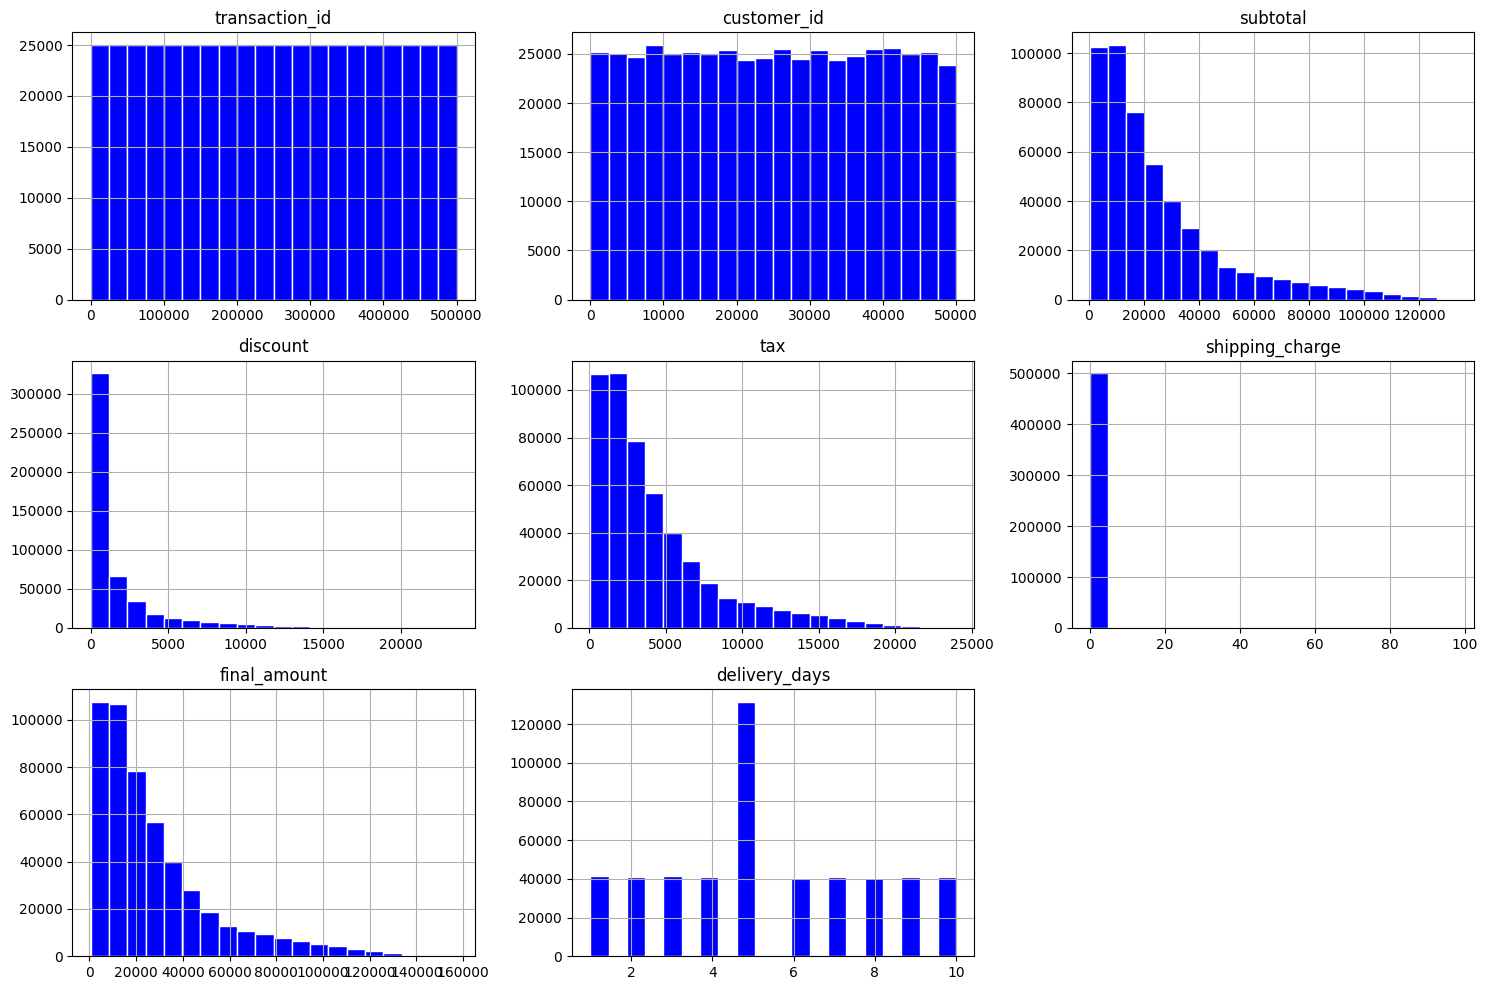

In [33]:
plt.figure(figsize=(12,5))
df[num_cols].hist(bins=20, figsize = (15,10), color='blue', edgecolor ='white')
plt.tight_layout()
plt.show()

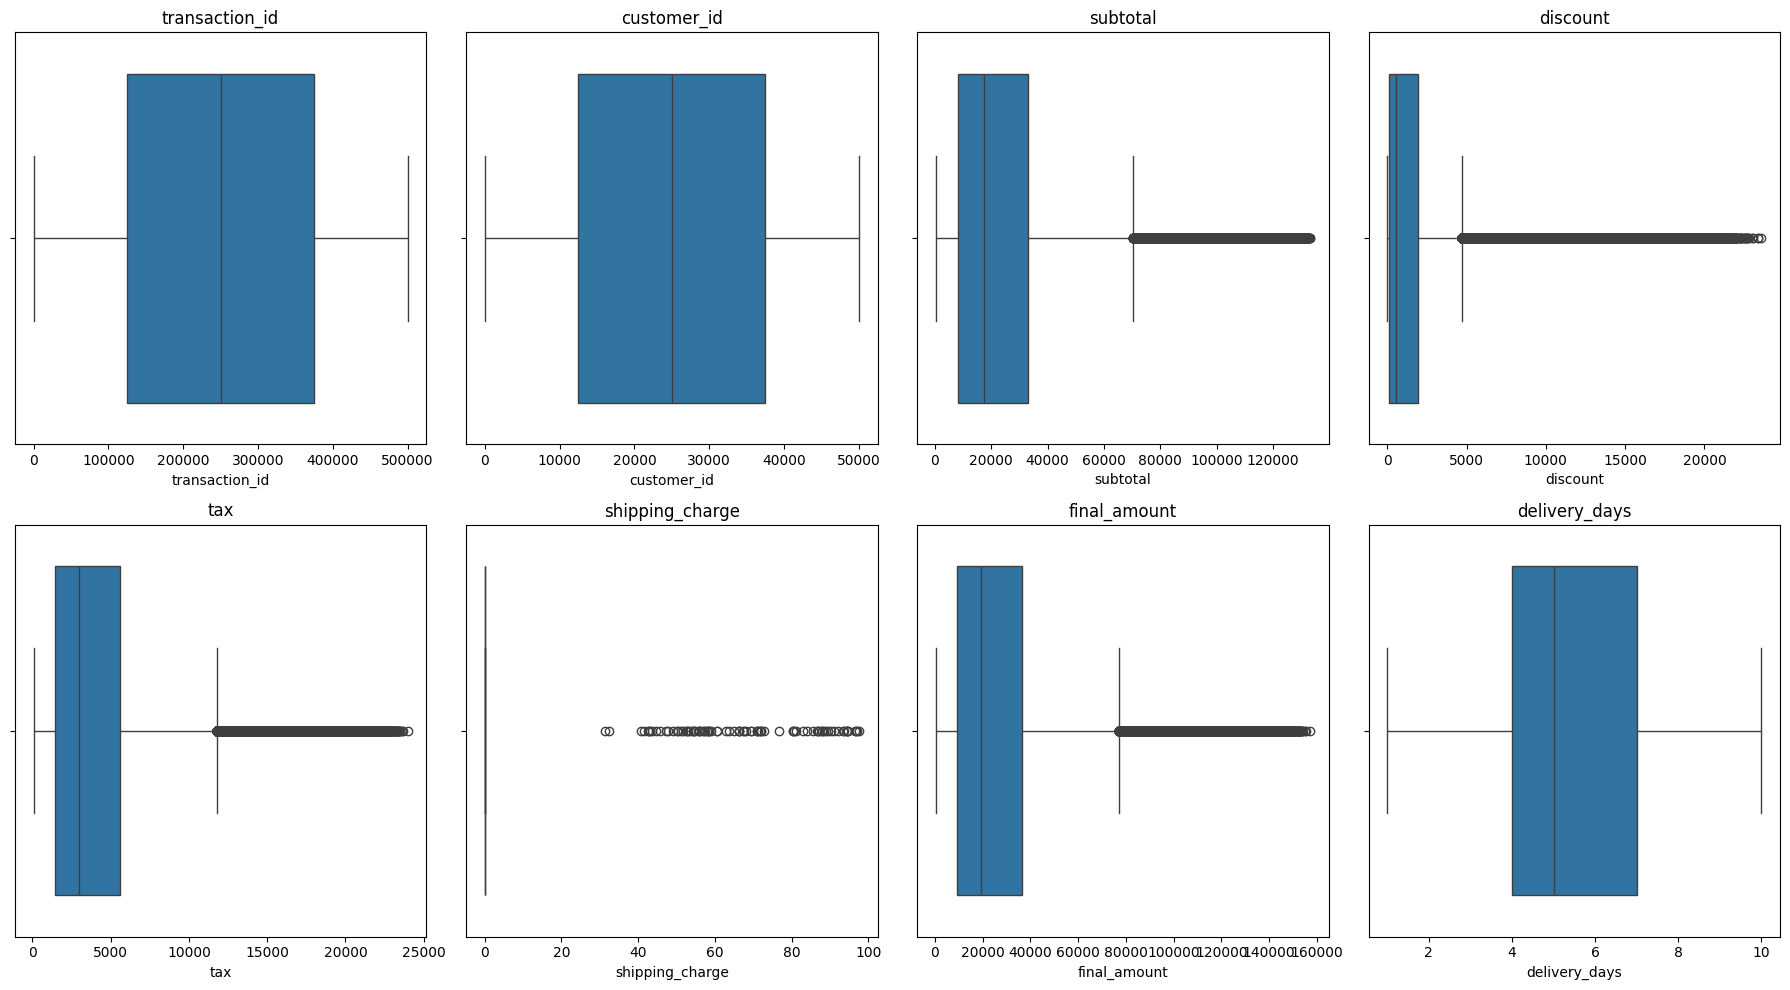

In [34]:

n_cols = 4 
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i], showfliers=True)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

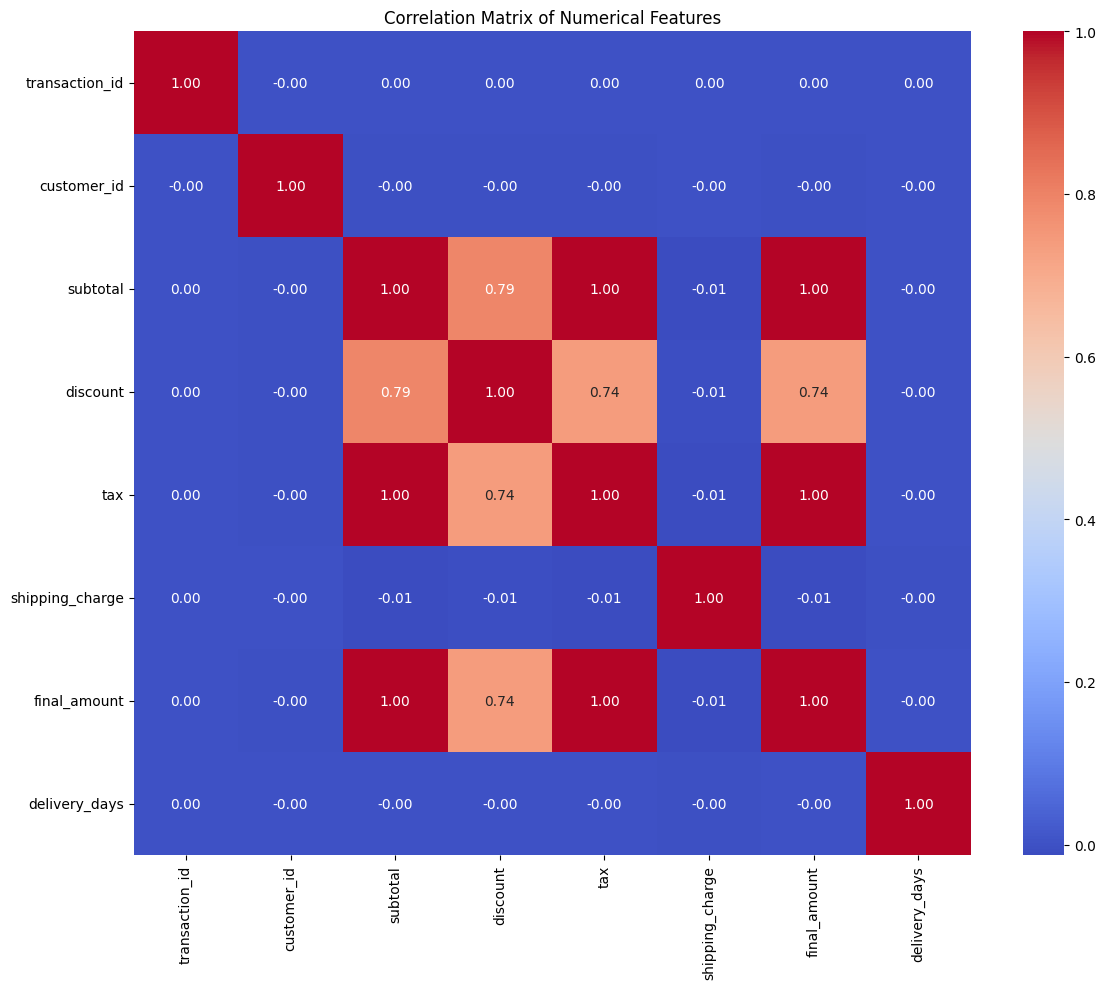

In [35]:
plt.figure(figsize=(12,10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [36]:
display(len(cat_cols))
display(df[cat_cols].columns)

5

Index(['order_date', 'payment_method', 'order_status', 'delivery_city',
       'delivery_state'],
      dtype='object')

In [37]:
df[cat_cols].head()

,order_date,payment_method,order_status,delivery_city,delivery_state
353368,2021-01-01 00:00:00,UPI,Delivered,Nashik,Maharashtra
170591,2021-01-01 00:00:00,UPI,Delivered,Chennai,Tamil Nadu
432704,2021-01-01 00:00:00,COD,Delivered,Patna,Bihar
92393,2021-01-01 00:00:00,Debit Card,Shipped,Lucknow,Uttar Pradesh
375201,2021-01-01 00:00:00,Credit Card,Delivered,Visakhapatnam,Andhra Pradesh
